# Retail Sales & Margin Analysis

Exploratory analysis of a retail product catalog and order history: category-level sales distribution, promo penetration, margin analysis, and ABC-classification of SKUs by revenue and volume contribution.

**Tools:** Python, Pandas, Seaborn, Matplotlib

**Data:** `products.xlsx` (product catalog: category / subcategory / product) and `orders.xlsx` (order-level transactions: quantity, regular price, actual price, cost price), joined on `product_id`. Sample data files are not included in this repository — see the project README for details.

> **Note:** the charts below are the outputs from the original analysis run and may still show Russian-language axis labels in a couple of places; the code has been updated to produce English labels the next time it runs against the source files.

## 1. Load & merge data

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
products = pd.read_excel('products.xlsx')

In [ ]:
products.head(1)

,product_id,level1,level2,name
0,1,Гигиена,Бритье,Кассеты для бритья Gillette Fusion ProGlide Po...


In [9]:
orders = pd.read_excel('orders.xlsx')

In [11]:
orders.head(1)

,order_id,accepted_at,product_id,quantity,regular_price,price,cost_price
0,1517514900,2022-01-13 16:48:19,17122,1,169,169,74


In [13]:
merged_df = products.merge(orders, on='product_id')

## 2. Category-level sales distribution

In [16]:
# Best-selling product category by units sold
df = merged_df.groupby('level1').agg({'quantity': 'sum'}).reset_index().sort_values('quantity', ascending=False)
df.head(5)

,level1,quantity
1,Безалкогольные напитки,534
11,Молочная продукция,483
19,Свежие овощи,262
10,Кулинария,250
0,Бакалея,239


[Text(0.5, 0, 'Product category'), Text(0, 0.5, 'Units sold')]

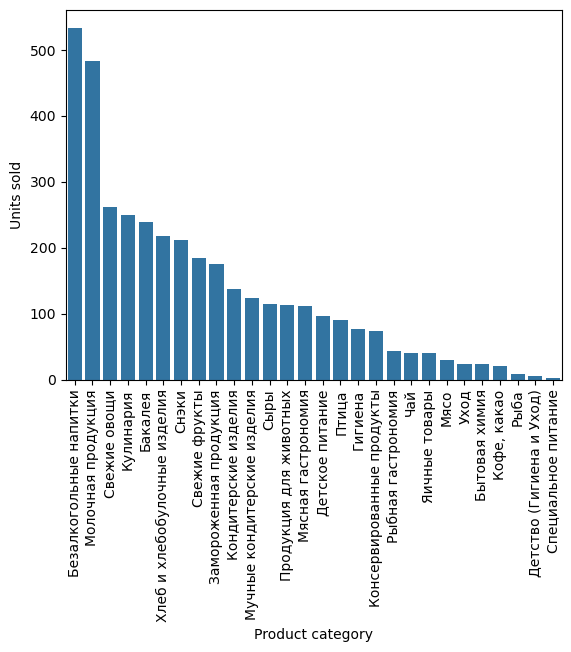

In [18]:
plot = sns.barplot(x=df['level1'], y=df['quantity'])
# Rotate axis tick labels for readability
plt.setp(plot.get_xticklabels(), rotation=90)
# Axis titles
plot.set(xlabel='Product category', ylabel='Units sold')

In [20]:
# Distribution of units sold within each category, broken down by subcategory
df = merged_df.groupby(['level1', 'level2']).agg({'quantity': 'sum'}).reset_index().sort_values('quantity', ascending=False)
df.head(5)

,level1,level2,quantity
13,Безалкогольные напитки,Напитки,252
54,Кулинария,Готовые блюда,248
95,Хлеб и хлебобулочные изделия,Хлеб и хлебобулочные изделия,218
86,Снэки,Снэки соленые,180
12,Безалкогольные напитки,Воды питьевые,162


## 3. Ad-hoc business question

Example of an ad-hoc query answered directly from the merged dataset.

In [23]:
# What was the average order value on 2022-01-13?
orders[orders['accepted_at'].dt.strftime('%Y-%m-%d') == '2022-01-13'].groupby('order_id')['price'].sum().reset_index()['price'].mean()

798.0422794117648

## 4. Promo penetration — Cheeses category

Share of items sold on promotion within a single category, used as a template for a category-by-category promo-effectiveness check.

In [58]:
# Share of items in the 'Сыры' (Cheeses) category sold on promotion
df = merged_df[merged_df['level1'] == 'Сыры']
df['is_promo'] = (df['regular_price'] > df['price'])
df.head(5)

C:\Users\Екатерина\AppData\Local\Temp\ipykernel_7744\3020036188.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['is_promo'] = (df['regular_price'] > df['price'])


,product_id,level1,level2,name,order_id,accepted_at,quantity,regular_price,price,cost_price,is_promo
116,1105,Сыры,Мягкие сыры,Сыр Моцарелла мини Самокат,1517510145,2022-01-13 19:22:00,2,129,129,73,False
117,1105,Сыры,Мягкие сыры,Сыр Моцарелла мини Самокат,1517609703,2022-01-13 08:46:56,1,116,116,73,False
118,1105,Сыры,Мягкие сыры,Сыр Моцарелла мини Самокат,1517675616,2022-01-13 18:23:57,1,129,129,73,False
119,1105,Сыры,Мягкие сыры,Сыр Моцарелла мини Самокат,1517521855,2022-01-13 19:57:03,1,129,129,73,False
265,2134,Сыры,Твердые сычужные сыры,Сыр сливочный Брест-Литовск,1517668073,2022-01-13 22:43:39,1,199,159,110,True


In [32]:
df[df['is_promo'] == True]['is_promo'].count() / df['is_promo'].count()

0.32075471698113206

In [34]:
label_map = {
    True: 'Promo',
    False: 'Not promo'
}

df = df.groupby('is_promo')['level1'].count().reset_index()
df['is_promo'] = df['is_promo'].map(label_map)

([<matplotlib.patches.Wedge at 0x19fd49d1100>,
 [Text(-0.5872057453381404, 0.9301555851801779, 'Not promo'),
  Text(0.5872057453381399, -0.9301555851801783, 'Promo')],
 [Text(-0.3202940429117129, 0.5073575919164606, '68%'),
  Text(0.32029404291171265, -0.5073575919164608, '32%')])

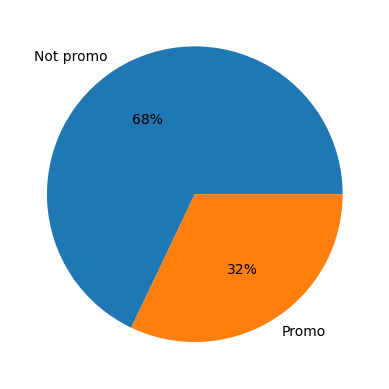

In [36]:
plt.pie(df['level1'], labels=df['is_promo'], autopct='%.0f%%')

## 5. Margin analysis by category

In [39]:
# Margin by category (absolute and %)
def calc_margin(x):
    d = {}
    d['margin_value'] = sum(x['price']) - sum(x['cost_price'])
    d['margin_perc'] = d['margin_value'] / sum(x['price'])
    return pd.Series(d, index=['margin_value', 'margin_perc'])

In [41]:
merged_df.head()

,product_id,level1,level2,name,order_id,accepted_at,quantity,regular_price,price,cost_price
0,23,Бакалея,Сухие блюда быстрого приготовления,Вермишель Роллтон,1517497108,2022-01-13 17:49:12,6,18,18,14
1,23,Бакалея,Сухие блюда быстрого приготовления,Вермишель Роллтон,1517494748,2022-01-13 20:12:01,2,18,18,14
2,23,Бакалея,Сухие блюда быстрого приготовления,Вермишель Роллтон,1517368853,2022-01-13 09:34:18,1,18,18,14
3,23,Бакалея,Сухие блюда быстрого приготовления,Вермишель Роллтон,1517676281,2022-01-13 08:21:53,2,18,18,14
4,23,Бакалея,Сухие блюда быстрого приготовления,Вермишель Роллтон,1517600286,2022-01-13 14:32:24,4,18,18,14


In [60]:
df = merged_df.groupby('level1').apply(calc_margin).reset_index()
df

C:\Users\Екатерина\AppData\Local\Temp\ipykernel_7744\2855298426.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = merged_df.groupby('level1').apply(calc_margin).reset_index()


,level1,margin_value,margin_perc
0,Бакалея,7224.0,0.383663
1,Безалкогольные напитки,15163.0,0.443103
2,Бытовая химия,1420.0,0.261270
3,Гигиена,2704.0,0.293466
4,Детское питание,1272.0,0.370306
5,Детство (Гигиена и Уход),517.0,0.299017
6,Замороженная продукция,11057.0,0.474244
7,Кондитерские изделия,4910.0,0.423130
8,Консервированные продукты,3635.0,0.420328
9,"Кофе, какао",3529.0,0.509382


[Text(0.5, 0, 'Margin (currency units)'), Text(0, 0.5, 'Product category')]

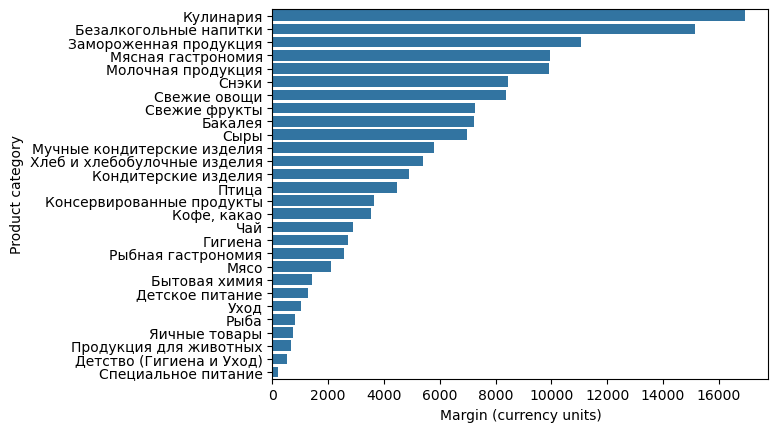

In [45]:
df_plot = df.sort_values('margin_value', ascending=False)

plot = sns.barplot(data=df_plot, y='level1', x='margin_value', orient='h')
plot.set(xlabel='Margin (currency units)', ylabel='Product category')

[Text(0.5, 0, 'Margin (%)'), Text(0, 0.5, 'Product category')]

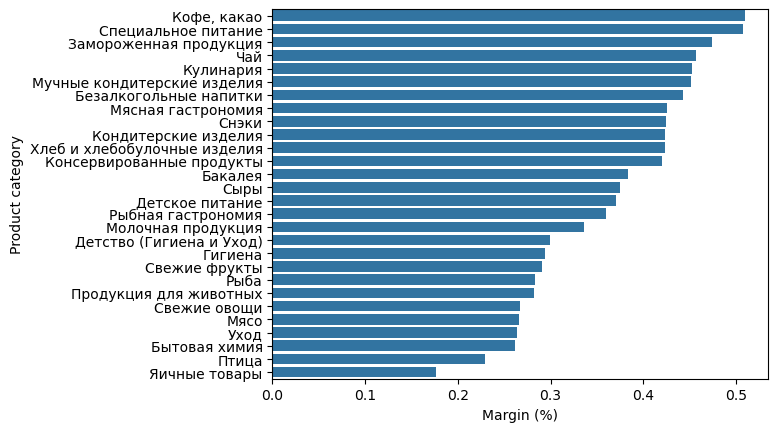

In [47]:
df_plot = df.sort_values('margin_perc', ascending=False)

plot = sns.barplot(data=df_plot, y='level1', x='margin_perc', orient='h')
plot.set(xlabel='Margin (%)', ylabel='Product category')

## 6. ABC-analysis

Classic Pareto-based classification: subcategories are ranked by cumulative contribution to revenue and to volume, and split into tiers A (top ~80% of cumulative contribution), B (next ~15%, up to 95%), and C (the long tail).

In [50]:
# ABC-analysis by quantity and by revenue
merged_df.head()

,product_id,level1,level2,name,order_id,accepted_at,quantity,regular_price,price,cost_price
0,23,Бакалея,Сухие блюда быстрого приготовления,Вермишель Роллтон,1517497108,2022-01-13 17:49:12,6,18,18,14
1,23,Бакалея,Сухие блюда быстрого приготовления,Вермишель Роллтон,1517494748,2022-01-13 20:12:01,2,18,18,14
2,23,Бакалея,Сухие блюда быстрого приготовления,Вермишель Роллтон,1517368853,2022-01-13 09:34:18,1,18,18,14
3,23,Бакалея,Сухие блюда быстрого приготовления,Вермишель Роллтон,1517676281,2022-01-13 08:21:53,2,18,18,14
4,23,Бакалея,Сухие блюда быстрого приготовления,Вермишель Роллтон,1517600286,2022-01-13 14:32:24,4,18,18,14


In [62]:
df = merged_df.groupby('level2').agg({'price': sum, 'quantity': sum}).reset_index()

df = df.sort_values('price', ascending=False)
df['price_contribution'] = df['price'] / sum(df['price'])
df['price_cumsum'] = df['price_contribution'].cumsum()

def set_abc(x):
    if x < 0.8: 
        return 'A'
    elif x < 0.95:
        return 'B'
    else:
        return 'C'
    
df['ABC_price'] = df['price_cumsum'].apply(set_abc)

df = df.sort_values('quantity', ascending=False)
df['quantity_contribution'] = df['quantity'] / sum(df['quantity'])
df['quantity_cumsum'] = df['quantity_contribution'].cumsum()
df['ABC_quantity'] = df['quantity_cumsum'].apply(set_abc) 

df['ABC_join'] = df.filter(like='ABC').apply(' '.join, axis=1)
df

C:\Users\Екатерина\AppData\Local\Temp\ipykernel_7744\3931049400.py:1: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  df = merged_df.groupby('level2').agg({'price': sum, 'quantity': sum}).reset_index()
C:\Users\Екатерина\AppData\Local\Temp\ipykernel_7744\3931049400.py:1: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  df = merged_df.groupby('level2').agg({'price': sum, 'quantity': sum}).reset_index()


,level2,price,quantity,price_contribution,price_cumsum,ABC_price,quantity_contribution,quantity_cumsum,ABC_quantity,ABC_join
51,Напитки,18320,252,0.047159,0.192202,A,0.067524,0.067524,A,A A
10,Готовые блюда,36944,248,0.095100,0.095100,A,0.066452,0.133976,A,A A
92,Хлеб и хлебобулочные изделия,12722,218,0.032748,0.420119,A,0.058414,0.192390,A,A A
72,Снэки соленые,15178,180,0.039071,0.318331,A,0.048232,0.240622,A,A A
6,Воды питьевые,5807,162,0.014948,0.702998,A,0.043408,0.284030,A,A A
...,...,...,...,...,...,...,...,...,...,...
56,Пасты кондитерские,518,2,0.001333,0.984151,C,0.000536,0.998392,C,C C
9,Готовая еда Самокат,484,2,0.001246,0.985397,C,0.000536,0.998928,C,C C
81,Средства по уходу за волосами,665,2,0.001712,0.972572,C,0.000536,0.999464,C,C C
77,Средства для сантехники,239,1,0.000615,0.997277,C,0.000268,0.999732,C,C C


In [54]:
df.filter(like='ABC').apply(' '.join, axis=1)

51    A A A A
10    A A A A
92    A A A A
72    A A A A
6     A A A A
       ...   
56    C C C C
9     C C C C
81    C C C C
77    C C C C
71    C C C C
Length: 100, dtype: object

## Key findings

- **Sales are concentrated in a handful of categories.** Non-alcoholic beverages, dairy, fresh vegetables, ready meals and dry goods/groceries account for the largest share of units sold; at the subcategory level, beverages, ready meals and bread dominate volume.
- **Promo penetration is material in Cheeses:** roughly **32%** of items sold in this category moved on a promotional price during the analyzed period.
- **Margins vary widely by category** — from ~23% (Poultry) up to ~50%+ (Coffee & cocoa, Specialty nutrition), with staples like Cheeses (~37%) and Beverages (~44%) in between. This spread is a natural input for pricing and promotion-budget decisions.
- **ABC-analysis** highlights a small set of subcategories responsible for the bulk of revenue and volume (Beverages, Ready meals, Bread) — the natural priority list for inventory attention, assortment planning and promotional focus, versus a long C-tier of low-impact subcategories.